# Final Model Evaluation & Production Selection
Picks the model that goes into `artifacts/` and gets deployed. Selection is based on cross-validated R² (`Best CV R2`), gated by how much a model overfits within cross-validation itself (`Train R2 - Best CV R2`) -- not by a single noisy train/test split, which proved too unstable on this dataset's ~70-row test set across earlier iterations of this notebook.

## Imports and paths

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

import dagshub
dagshub.init(repo_owner='kushneek', repo_name='smartwatch-rating-prediction', mlflow=True)


import mlflow
import mlflow.sklearn
mlflow.set_experiment("smartwatch-rating")

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "Dataset"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
TUNED_DIR = EXPERIMENTS_DIR / "tuned_models"
RESULTS_DIR = PROJECT_ROOT / "results"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"


Accessing as kushneek

Initialized MLflow to track repo "kushneek/smartwatch-rating-prediction"

Repository kushneek/smartwatch-rating-prediction initialized!

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data and tuning results

In [2]:
X_train = pd.read_csv(DATA_DIR / "split" / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "split" / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "split" / "y_train.csv").squeeze()
y_test = pd.read_csv(DATA_DIR / "split" / "y_test.csv").squeeze()

X_train_scaled = pd.read_csv(DATA_DIR / "split" / "X_train_scaled.csv")
X_test_scaled = pd.read_csv(DATA_DIR / "split" / "X_test_scaled.csv")

tuning_results = pd.read_csv(RESULTS_DIR / "Hyperparameter_Tuning_Results.csv")
tuning_results


,Model,Best Parameters,Best CV R2,Train R2,Test R2,Train-Test Gap
0,Decision Tree,"{'max_depth': 4, 'min_samples_leaf': 4, 'min_s...",0.114048,0.396401,0.435154,-0.038753
1,Lasso,{'alpha': 0.01},0.174329,0.265998,0.357436,-0.091438
2,Random Forest,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.163013,0.475292,0.342651,0.132640
3,Ridge,{'alpha': 100},0.159897,0.253133,0.340583,-0.087450
4,Gradient Boosting,"{'learning_rate': 0.03, 'max_depth': 2, 'min_s...",0.128765,0.507223,0.284613,0.222610
5,KNN,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.062848,0.288696,0.263897,0.024800
6,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.232572,0.704587,0.027288,0.677298


## Load all tuned models

In [3]:
scaled_models = ["Ridge", "Lasso", "KNN"]

models = {}
for name in tuning_results["Model"]:
    filename = name.replace(" ", "_") + ".joblib"
    models[name] = joblib.load(TUNED_DIR / filename)

list(models.keys())


['Decision Tree',
 'Lasso',
 'Random Forest',
 'Ridge',
 'Gradient Boosting',
 'KNN',
 'XGBoost']

## Selection rule
A model qualifies only if it clears BOTH:
- `CV_Gap` (Train R² minus CV R²) is small -- meaning it isn't overfitting within cross-validation itself
- `Best CV R2` clears a minimum floor -- meaning a low gap isn't just because the model is too weak to overfit in the first place

If nothing clears both, the fallback is the highest CV R² regardless of gap -- and that fallback gets recorded honestly in `metadata.json`, not disguised as a clean pass.

In [4]:
GAP_THRESHOLD = 0.20
CV_R2_FLOOR = 0.15

tuning_results["CV_Gap"] = tuning_results["Train R2"] - tuning_results["Best CV R2"]

eligible = tuning_results[
    (tuning_results["CV_Gap"] <= GAP_THRESHOLD) &
    (tuning_results["Best CV R2"] >= CV_R2_FLOOR)
].copy()

if eligible.empty:
    print("No model meets both thresholds -- falling back to highest CV R2 regardless of gap.")
    eligible = tuning_results.sort_values("Best CV R2", ascending=False).head(1)
    used_fallback = True
else:
    eligible = eligible.sort_values("Best CV R2", ascending=False)
    used_fallback = False

best_model_name = eligible.iloc[0]["Model"]
print(f"Selected model: {best_model_name}")
print(eligible[["Model", "Best CV R2", "Train R2", "CV_Gap"]])


Selected model: Lasso
   Model  Best CV R2  Train R2    CV_Gap
1  Lasso    0.174329  0.265998  0.091670
3  Ridge    0.159897  0.253133  0.093236


## Cross-validated score for the selected model

In [5]:
best_model = models[best_model_name]
X_used = X_train_scaled if best_model_name in scaled_models else X_train

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_used, y_train, cv=kf, scoring="r2", n_jobs=1)

print(f"CV R2 scores: {np.round(cv_scores, 4)}")
print(f"CV R2 mean:   {cv_scores.mean():.4f}")
print(f"CV R2 std:    {cv_scores.std():.4f}")


CV R2 scores: [-0.0046  0.2929  0.1509  0.1849  0.2475]
CV R2 mean:   0.1743
CV R2 std:    0.1021


## Final test-set metrics for the selected model

In [6]:
X_te = X_test_scaled if best_model_name in scaled_models else X_test

y_pred = best_model.predict(X_te)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n, p = X_te.shape
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"MAE:          {mae:.4f}")
print(f"RMSE:         {rmse:.4f}")
print(f"Test R2:      {r2:.4f}")
print(f"Adjusted R2:  {adjusted_r2:.4f}")


MAE:          0.2284
RMSE:         0.3582
Test R2:      0.3574
Adjusted R2:  0.0567


## Diagnostic plots

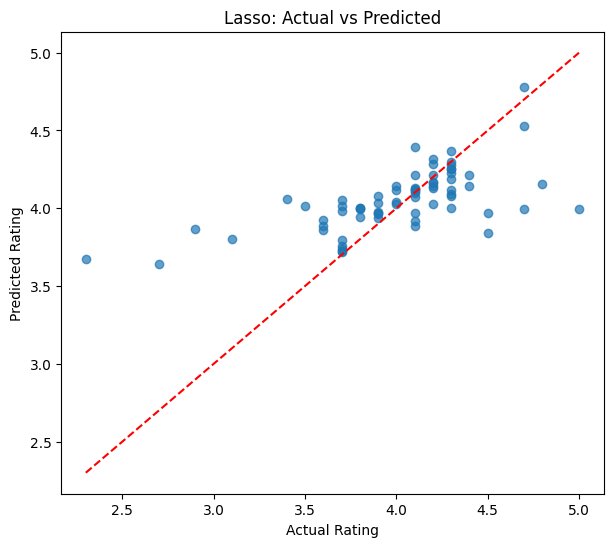

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title(f"{best_model_name}: Actual vs Predicted")
plt.show()


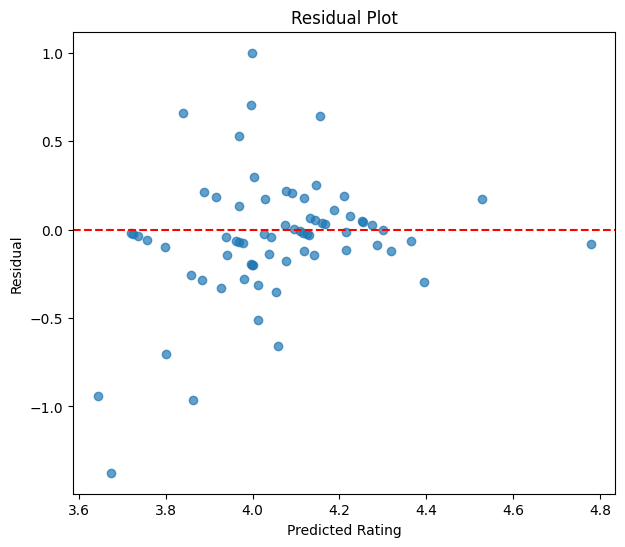

In [8]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Rating")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


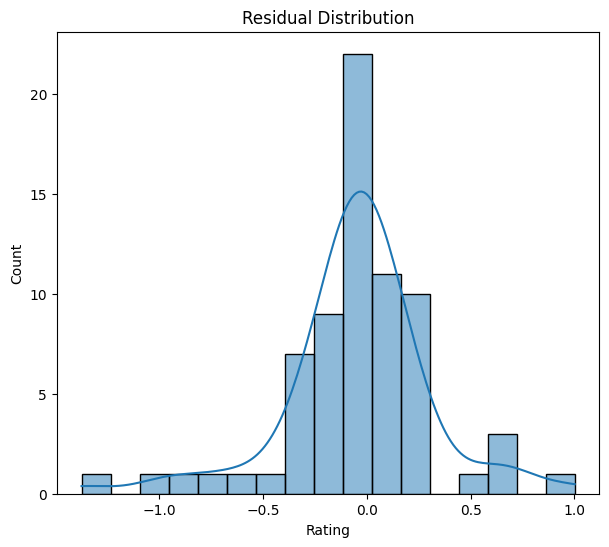

In [9]:
plt.figure(figsize=(7, 6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


## Feature importance / coefficients (if the selected model supports it)

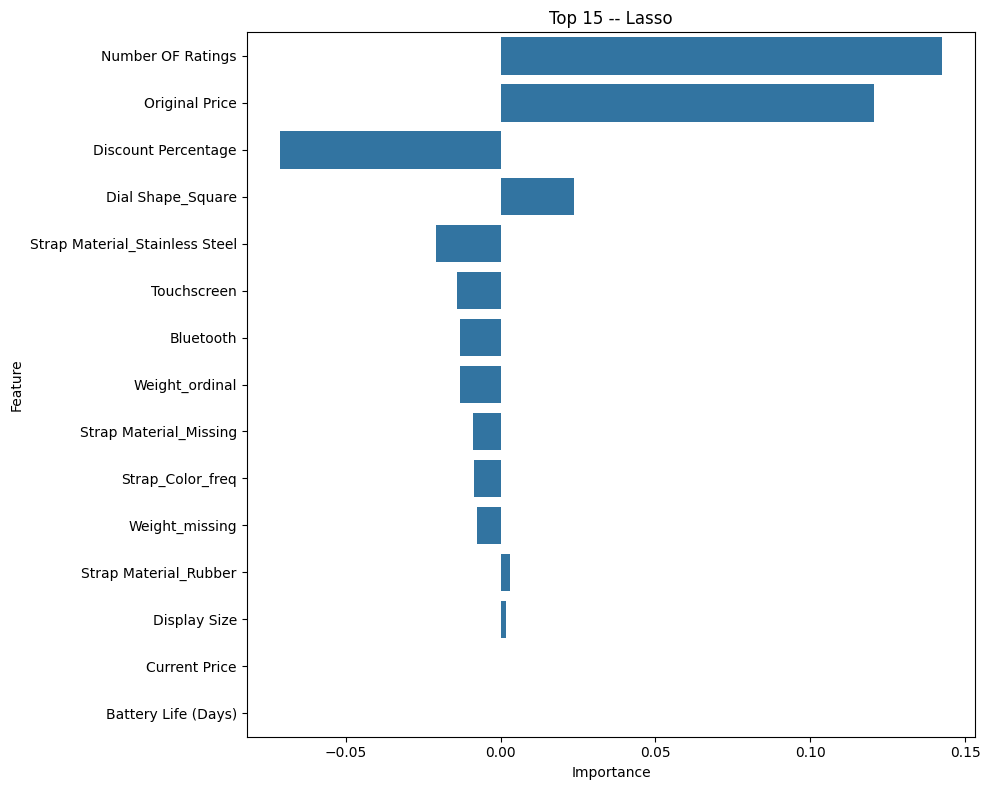

                           Feature  Importance
3                Number OF Ratings    0.142605
1                   Original Price    0.120488
2              Discount Percentage   -0.071297
16               Dial Shape_Square    0.023846
21  Strap Material_Stainless Steel   -0.020688
11                     Touchscreen   -0.014139
12                       Bluetooth   -0.013027
9                   Weight_ordinal   -0.013023
17          Strap Material_Missing   -0.008751
8                 Strap_Color_freq   -0.008452
6                   Weight_missing   -0.007467
19           Strap Material_Rubber    0.002901
5                     Display Size    0.001637
0                    Current Price    0.000000
4              Battery Life (Days)    0.000000


In [10]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.DataFrame({
        "Feature": X_used.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)
elif hasattr(best_model, "coef_"):
    importance = pd.DataFrame({
        "Feature": X_used.columns,
        "Importance": best_model.coef_
    }).sort_values("Importance", key=abs, ascending=False)
else:
    importance = None

if importance is not None:
    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance.head(15), x="Importance", y="Feature")
    plt.title(f"Top 15 -- {best_model_name}")
    plt.tight_layout()
    plt.show()
    print(importance.head(15))


## Save production artifacts

In [11]:
joblib.dump(best_model, ARTIFACTS_DIR / "model.joblib")

metadata = {
    "model_name": best_model_name,
    "trained_at": datetime.now().isoformat(),
    "needs_scaling": best_model_name in scaled_models,
    "n_train_rows": int(X_train.shape[0]),
    "n_test_rows": int(X_test.shape[0]),
    "n_features": int(X_used.shape[1]),
    "cv_r2_mean": float(cv_scores.mean()),
    "cv_r2_std": float(cv_scores.std()),
    "test_r2": float(r2),
    "test_adjusted_r2": float(adjusted_r2),
    "test_mae": float(mae),
    "test_rmse": float(rmse),
    "cv_gap": float(eligible.iloc[0]["CV_Gap"]),
    "selection_rule": (
        f"No model met CV_Gap<={GAP_THRESHOLD} and CV R2>={CV_R2_FLOOR}; fell back to highest CV R2 ({best_model_name})"
        if used_fallback else
        f"CV_Gap <= {GAP_THRESHOLD} and CV R2 >= {CV_R2_FLOOR}, then highest CV R2"
    ),
}

with open(ARTIFACTS_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))


{
  "model_name": "Lasso",
  "trained_at": "2026-08-03T08:58:27.242385",
  "needs_scaling": true,
  "n_train_rows": 277,
  "n_test_rows": 70,
  "n_features": 22,
  "cv_r2_mean": 0.17432867385533704,
  "cv_r2_std": 0.1020878657653364,
  "test_r2": 0.3574362863757662,
  "test_adjusted_r2": 0.056661782126124716,
  "test_mae": 0.2283781143178226,
  "test_rmse": 0.3581646888370615,
  "cv_gap": 0.09166958838385841,
  "selection_rule": "CV_Gap <= 0.2 and CV R2 >= 0.15, then highest CV R2"
}


## Log the production model to DagsHub

In [12]:
with mlflow.start_run(run_name=f"{best_model_name}_PRODUCTION"):
    mlflow.log_params({"selection_rule": metadata["selection_rule"]})
    mlflow.log_metrics({
        "cv_r2_mean": metadata["cv_r2_mean"],
        "test_r2": metadata["test_r2"],
        "test_mae": metadata["test_mae"],
        "cv_gap": metadata["cv_gap"],
    })
    mlflow.sklearn.log_model(best_model, name="model")
    mlflow.set_tag("stage", "production")

print("Logged to DagsHub as production run.")


2026/08/03 08:58:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Lasso_PRODUCTION at: https://dagshub.com/kushneek/smartwatch-rating-prediction.mlflow/#/experiments/0/runs/64f9ce82051340bdb96bf7c27fc62200
🧪 View experiment at: https://dagshub.com/kushneek/smartwatch-rating-prediction.mlflow/#/experiments/0
Logged to DagsHub as production run.


## Full model comparison table

In [13]:
comparison_rows = []

for name, model in models.items():
    X_tr = X_train_scaled if name in scaled_models else X_train
    X_te_i = X_test_scaled if name in scaled_models else X_test
    pred = model.predict(X_te_i)

    comparison_rows.append({
        "Model": name,
        "Train R2": model.score(X_tr, y_train),
        "Test R2": model.score(X_te_i, y_test),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Selected": name == best_model_name,
    })

final_comparison = pd.DataFrame(comparison_rows).sort_values("Test R2", ascending=False)
final_comparison.to_csv(RESULTS_DIR / "Final_Model_Comparison.csv", index=False)
final_comparison


,Model,Train R2,Test R2,MAE,RMSE,Selected
0,Decision Tree,0.396401,0.435154,0.243858,0.335807,False
1,Lasso,0.265998,0.357436,0.228378,0.358165,True
2,Random Forest,0.475292,0.342651,0.230847,0.362262,False
3,Ridge,0.253133,0.340583,0.239324,0.362831,False
4,Gradient Boosting,0.507223,0.284613,0.245014,0.377916,False
5,KNN,0.288696,0.263897,0.251020,0.383349,False
6,XGBoost,0.704587,0.027288,0.260159,0.440673,False
